# Livrable 1 : Modélisation du Problème d'Optimisation de Tournée de Véhicules avec Contraintes

## Projet CesiCDP - Réponse à l'Appel à Manifestations d'Intérêt ADEME

---

## 1. Introduction et Contexte

### 1.1 Contexte Environnemental Global

Depuis les années 90, une prise de conscience mondiale s'est opérée concernant la nécessité urgente de réduire la consommation d'énergie et les émissions de gaz à effet de serre. Les premiers engagements internationaux sont apparus avec le **Protocole de Kyoto en 1997**, suivi par des engagements plus ambitieux comme la division par 4 des émissions d'ici 2050 pour la France.

Cependant, les pouvoirs publics et collectivités territoriales ne peuvent imposer directement de nouvelles pratiques aux entreprises et particuliers. L'action se porte donc sur **l'accompagnement du changement de comportements**, notamment dans les domaines :
- De l'économie et du recyclage des matières premières
- De l'amélioration des modes de transport
- De la performance énergétique des bâtiments

### 1.2 Mission CesiCDP pour l'ADEME

L'**ADEME** (Agence de l'Environnement et de la Maîtrise de l'Énergie) a lancé un appel à manifestations d'intérêt pour promouvoir des démonstrateurs de nouvelles solutions de **mobilité multimodale intelligente** pour les personnes et les marchandises.

**CesiCDP**, structure déjà implantée dans le domaine avec de nombreux partenaires, répond à cet appel. Notre mission : développer des solutions algorithmiques capables d'optimiser la logistique de transport pour :
- 📦 La distribution du courrier
- 🚚 La livraison de produits
- 🗑️ Le traitement du réseau routier et ramassage des ordures

### 1.3 Problématique Cible

L'objectif central est de **limiter les déplacements et la consommation des véhicules** lors de livraisons. Le problème algorithmique consiste à :

> *Calculer sur un réseau routier une tournée permettant de relier un sous-ensemble de villes, puis de revenir au point de départ, de manière à **minimiser la durée totale** de la tournée.*

### 1.4 Spécificités du Problème Traité

Contrairement au problème classique du Voyageur de Commerce (TSP), notre contexte réel impose des **contraintes opérationnelles** :

| Contrainte | Description | Exemple Concret |
|------------|-------------|-----------------|
| **Fenêtres Temporelles** | Chaque ville doit être visitée dans un intervalle de temps donné | Un client n'est disponible que de 8h à 10h |
| **Restrictions de Passage** | Certaines routes sont plus coûteuses ou interdites | Travaux, zones à faibles émissions, routes bloquées |

Ces contraintes transforment le problème en un **TSPTW** (Traveling Salesperson Problem with Time Windows) avec restrictions d'arêtes, un problème significativement plus complexe que sa version de base.

### 1.5 Organisation du Livrable

Ce document présente :
1. ✅ La modélisation formelle du problème (graphe, variables, contraintes)
2. ✅ La génération d'instances de test réalistes
3. ✅ L'analyse de complexité théorique

*Les méthodes de résolution algorithmiques seront traitées dans les livrables suivants.*

## 2. Modélisation Formelle et Mathématique

### 2.1 Représentation du Problème

Nous modélisons le réseau de transport sous la forme d'un **graphe orienté** $G = (V, E)$ où :

| Élément | Notation | Description |
|---------|----------|-------------|
| **Nœuds** | $V = \{0, 1, 2, ..., n\}$ | Ensemble de $n+1$ nœuds |
| **Dépôt** | $0$ | Point de départ et d'arrivée du véhicule |
| **Clients** | $V' = \{1, 2, ..., n\}$ | Ensemble des $n$ villes/clients à visiter |
| **Arêtes** | $E \subseteq V \times V$ | Routes reliant les nœuds (le graphe n'est pas nécessairement complet) |

### 2.2 Paramètres et Données

| Paramètre | Notation | Type | Description |
|-----------|----------|------|-------------|
| Coût de trajet | $c_{ij}$ | $\mathbb{R}^+ \cup \{+\infty\}$ | Coût (ou temps) pour parcourir l'arête $(i,j)$ |
| Durée de trajet | $d_{ij}$ | $\mathbb{R}^+$ | Temps de transport entre $i$ et $j$ |
| Fenêtre temporelle | $[e_i, l_i]$ | $\mathbb{R}^+ \times \mathbb{R}^+$ | Intervalle de disponibilité du nœud $i$ |
| Constante Big-M | $M$ | $\mathbb{R}^+$ | Grande constante pour linéarisation |

**Gestion des restrictions de passage :**
- Route normale : $c_{ij} \in \mathbb{R}^+$ (coût standard)
- Route coûteuse : $c_{ij}$ élevé (péage, zone congestionnée)
- **Route interdite** : $c_{ij} = +\infty$ (travaux, interdiction permanente)

### 2.3 Variables de Décision

Deux types de variables sont nécessaires pour modéliser le problème :

**Variables de routage (binaires) :**
$$x_{ij} = \begin{cases} 
1 & \text{si le véhicule emprunte l'arête } (i,j) \\
0 & \text{sinon}
\end{cases} \quad \forall (i,j) \in E$$

**Variables temporelles (continues) :**
$$t_i \geq 0 : \text{heure de début de service au nœud } i, \quad \forall i \in V$$

### 2.4 Fonction Objectif

Minimiser le coût total de la tournée (somme des coûts des arêtes empruntées) :

$$\min Z = \sum_{i \in V} \sum_{j \in V, j \neq i} c_{ij} \cdot x_{ij}$$

*Note : Minimiser le coût équivaut à minimiser la durée totale si $c_{ij} = d_{ij}$.*

### 2.5 Contraintes du Modèle

#### Contrainte 1 : Visite unique de chaque client

Chaque nœud client ($i \in V'$) doit avoir **exactement un prédécesseur** et **exactement un successeur** :

$$\sum_{j \in V, j \neq i} x_{ji} = 1 \quad \forall i \in V' \quad \text{(un arc entre dans chaque client)}$$

$$\sum_{j \in V, j \neq i} x_{ij} = 1 \quad \forall i \in V' \quad \text{(un arc sort de chaque client)}$$

#### Contrainte 2 : Départ et retour au dépôt

Le véhicule doit quitter le dépôt exactement une fois et y retourner exactement une fois :

$$\sum_{j \in V'} x_{0j} = 1 \quad \text{(départ du dépôt)}$$

$$\sum_{j \in V'} x_{j0} = 1 \quad \text{(retour au dépôt)}$$

#### Contrainte 3 : Continuité temporelle et élimination des sous-tours

Si le véhicule va de $i$ à $j$ ($x_{ij} = 1$), alors l'heure d'arrivée en $j$ doit être cohérente avec l'heure de départ de $i$ :

$$t_i + d_{ij} - M \cdot (1 - x_{ij}) \leq t_j \quad \forall i,j \in V, i \neq j$$

**Explication :**
- Si $x_{ij} = 1$ : la contrainte devient $t_i + d_{ij} \leq t_j$ (on arrive en $j$ après avoir voyagé depuis $i$)
- Si $x_{ij} = 0$ : la contrainte devient $t_i + d_{ij} - M \leq t_j$, toujours vraie pour $M$ suffisamment grand

*Rôle secondaire : cette contrainte élimine les sous-tours en imposant une croissance stricte des temps le long du cycle.*

#### Contrainte 4 : Respect des fenêtres temporelles

Chaque visite doit intervenir dans l'intalle de temps autorisé :

$$e_i \leq t_i \leq l_i \quad \forall i \in V$$

**Cas particuliers :**
- Dépôt : $[e_0, l_0] = [0, 24]$ (pas de restriction)
- Client matinal : $[e_i, l_i] = [8, 10]$ (livraison matinée uniquement)
- Client après-midi : $[e_i, l_i] = [14, 17]$ (livraison après-midi uniquement)

#### Contrainte 5 : Interdiction des routes bloquées

Pour toute arête interdite $(i,j) \in E_{bloquées}$ :

$$x_{ij} = 0 \quad \forall (i,j) \in E_{bloquées}$$

*En pratique, on peut aussi simplement omettre ces arêtes de $E$ lors de la construction du graphe.*

#### Contrainte 6 : Domaine des variables

$$x_{ij} \in \{0, 1\} \quad \forall (i,j) \in E$$

$$t_i \geq 0 \quad \forall i \in V$$

---

### 2.6 Synthèse du Modèle

| Élément | Description |
|---------|-------------|
| **Type de problème** | TSPTW (Traveling Salesperson Problem with Time Windows) |
| **Variables binaires** | $(n+1)^2$ variables $x_{ij}$ |
| **Variables continues** | $n+1$ variables $t_i$ |
| **Contraintes principales** | $2n + 2 + (n+1)^2 + 2(n+1)$ |
| **Objectif** | Minimisation linéaire |

### 2.7 Illustration Graphique du Modèle

Pour visualiser notre modélisation, voici un exemple de graphe avec :
- Les **fenêtres temporelles** affichées sous chaque nœud
- Les **coûts normaux** des routes en noir
- Les **routes bloquées** (travaux/interdites) en rouge pointillé avec coût $\infty$

---

## 3. Génération d'Instances Aléatoires

Pour tester et valider nos algorithmes de résolution, nous devons générer des instances de test réalistes représentant différents scénarios de livraison.

### 3.1 Choix des Paramètres de Génération

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| **Nombre de clients (n)** | 5 à 100 | Petites instances (5-20) pour validation exacte, grandes instances (50-100) pour heuristiques |
| **Type de graphe** | Complet ou partiel | Graphe complet par défaut, avec option de suppression d'arêtes pour simuler un réseau routier réaliste |
| **Distribution spatiale** | Coordonnées 2D uniformes | Représente des clients répartis sur un territoire rectangulaire |
| **Coûts des arêtes** | Distance euclidienne | Les coûts sont proportionnels aux distances géographiques |
| **Fenêtres temporelles** | Aléatoires avec recouvrement | Différents profils : matinal (8h-12h), après-midi (14h-18h), journée complète |
| **Taux de routes bloquées** | 5% à 20% | Simule des travaux, zones interdites, ou restrictions temporaires |

### 3.2 Algorithme de Génération

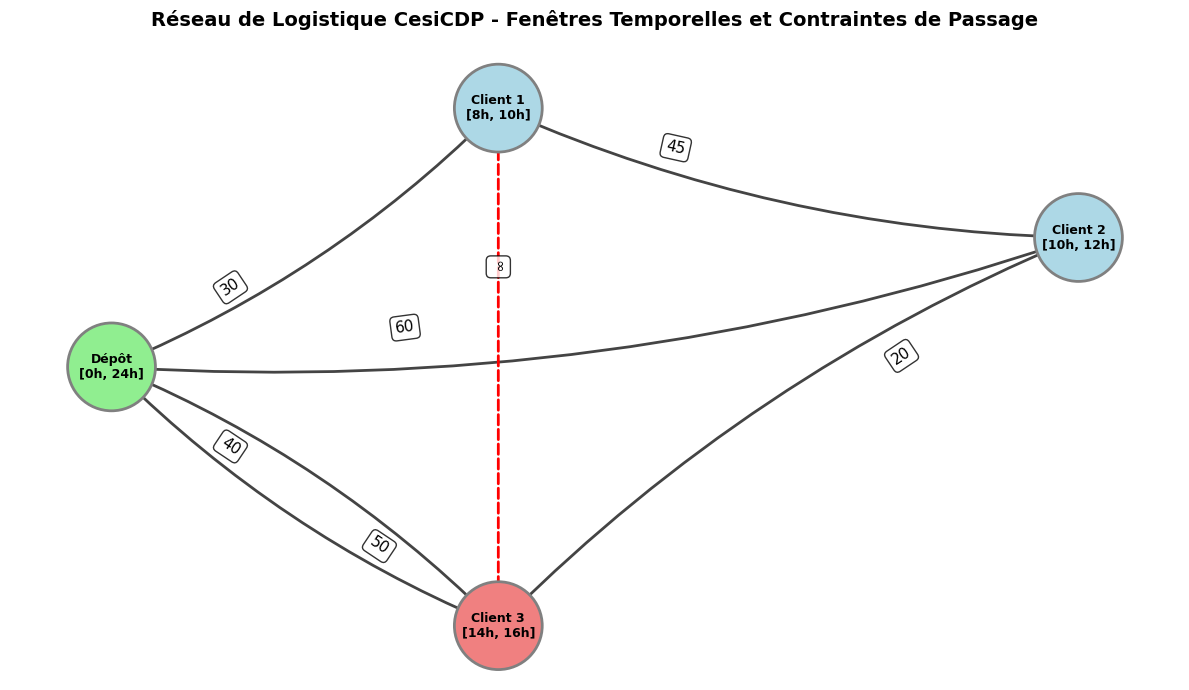

Légende :
  🟢 Dépôt (point de départ/arrivée)
  🔵 Clients avec fenêtres temporelles
  🔴 Client avec fenêtre l'après-midi
  ➖ Route bloquée/interdite (rouge pointillé)


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Création d'un graphe orienté pour l'exemple
G = nx.DiGraph()

# Définition des nœuds avec positions, labels et fenêtres temporelles
nodes = {
    0: {"pos": (0, 0), "label": "Dépôt\n[0h, 24h]", "color": "lightgreen"},
    1: {"pos": (2, 2), "label": "Client 1\n[8h, 10h]", "color": "lightblue"},
    2: {"pos": (5, 1), "label": "Client 2\n[10h, 12h]", "color": "lightblue"},
    3: {"pos": (2, -2), "label": "Client 3\n[14h, 16h]", "color": "lightcoral"},
}

for n, attr in nodes.items():
    G.add_node(n, pos=attr["pos"], label=attr["label"], color=attr["color"])

# Routes normales avec leurs coûts (temps de trajet en minutes)
normal_edges = [
    (0, 1, 30), (1, 2, 45), (2, 3, 20),
    (3, 0, 50), (0, 3, 40), (0, 2, 60)
]
for u, v, w in normal_edges:
    G.add_edge(u, v, weight=w)

# Route bloquée (travaux) - coût infini
blocked_edge = (1, 3)
G.add_edge(blocked_edge[0], blocked_edge[1], weight=float('inf'))

# Configuration de l'affichage
plt.figure(figsize=(12, 7))
pos = nx.get_node_attributes(G, 'pos')
node_colors = [data["color"] for _, data in G.nodes(data=True)]

# Dessin des nœuds
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color=node_colors, edgecolors="gray", linewidths=2)
nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, 'label'), 
                        font_size=9, font_weight="bold")

# Dessin des arêtes normales
nx.draw_networkx_edges(G, pos, edgelist=normal_edges, 
                       arrowstyle='->', arrowsize=25, 
                       edge_color='#444444', width=2,
                       connectionstyle='arc3,rad=0.1')

# Dessin de la route bloquée
nx.draw_networkx_edges(G, pos, edgelist=[blocked_edge], 
                       style='dashed', edge_color='red', 
                       arrowstyle='-|>', arrowsize=25, width=2)

# Affichage des poids sur les arêtes
edge_labels = {(u, v): "∞" if d['weight'] == float('inf') else str(d['weight']) 
               for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                             label_pos=0.3, font_size=11, 
                             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.title("Réseau de Logistique CesiCDP - Fenêtres Temporelles et Contraintes de Passage", 
          fontsize=14, fontweight="bold", pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Légende :")
print("  🟢 Dépôt (point de départ/arrivée)")
print("  🔵 Clients avec fenêtres temporelles")
print("  🔴 Client avec fenêtre l'après-midi")
print("  ➖ Route bloquée/interdite (rouge pointillé)")

In [2]:
import random
import math
from typing import Dict, List, Tuple, Optional

class InstanceGenerator:
    """
    Générateur d'instances pour le TSPTW avec contraintes de passage.
    
    Paramètres configurables :
    - n_clients : nombre de clients à visiter (hors dépôt)
    - width, height : dimensions du territoire (km)
    - blocked_ratio : proportion de routes bloquées (0 à 0.5)
    - time_window_type : 'tight' (serrées) ou 'loose' (larges)
    - seed : graine aléatoire pour reproductibilité
    """
    
    def __init__(self, n_clients: int = 10, 
                 width: float = 100.0, 
                 height: float = 100.0,
                 blocked_ratio: float = 0.1,
                 time_window_type: str = 'tight',
                 seed: Optional[int] = None):
        self.n_clients = n_clients
        self.width = width
        self.height = height
        self.blocked_ratio = blocked_ratio
        self.time_window_type = time_window_type
        self.seed = seed
        
        if seed is not None:
            random.seed(seed)
    
    def generate_coordinates(self) -> Dict[int, Tuple[float, float]]:
        """
        Génère les coordonnées (x, y) de tous les nœuds.
        Le dépôt (nœud 0) est toujours à l'origine (0, 0).
        """
        coords = {0: (0.0, 0.0)}  # Dépôt à l'origine
        
        for i in range(1, self.n_clients + 1):
            x = random.uniform(0, self.width)
            y = random.uniform(0, self.height)
            coords[i] = (x, y)
        
        return coords
    
    def euclidean_distance(self, 
                          p1: Tuple[float, float], 
                          p2: Tuple[float, float]) -> float:
        """Calcule la distance euclidienne entre deux points."""
        return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
    
    def generate_costs(self, 
                      coords: Dict[int, Tuple[float, float]]) -> Dict[Tuple[int, int], float]:
        """
        Génère la matrice des coûts basée sur les distances.
        Retourne un dictionnaire {(i,j): cost} pour toutes les paires.
        """
        costs = {}
        for i in range(self.n_clients + 1):
            for j in range(self.n_clients + 1):
                if i != j:
                    dist = self.euclidean_distance(coords[i], coords[j])
                    costs[(i, j)] = round(dist, 2)
        return costs
    
    def generate_blocked_edges(self, 
                               all_edges: List[Tuple[int, int]]) -> List[Tuple[int, int]]:
        """
        Sélectionne aléatoirement les arêtes bloquées.
        Le dépôt reste toujours accessible (pas de blocage vers/depuis le dépôt).
        """
        blockable_edges = [(i, j) for i, j in all_edges if i != 0 and j != 0]
        n_blocked = max(1, int(len(blockable_edges) * self.blocked_ratio))
        blocked = random.sample(blockable_edges, min(n_blocked, len(blockable_edges)))
        return blocked
    
    def generate_time_windows(self) -> Dict[int, Tuple[float, float]]:
        """
        Génère les fenêtres temporelles pour chaque nœud.
        """
        windows = {}
        windows[0] = (0.0, 24.0)  # Dépôt ouvert 24h/24
        
        if self.time_window_type == 'tight':
            window_duration = 2.0
            possible_starts = [8, 9, 10, 14, 15, 16]
        elif self.time_window_type == 'loose':
            window_duration = 4.0
            possible_starts = [8, 12]
        else:  # mixed
            window_duration = 3.0
            possible_starts = [8, 10, 14, 16]
        
        for i in range(1, self.n_clients + 1):
            start_hour = random.choice(possible_starts)
            end_hour = start_hour + window_duration
            windows[i] = (float(start_hour), float(end_hour))
        
        return windows
    
    def generate(self) -> dict:
        """Génère une instance complète du problème."""
        coords = self.generate_coordinates()
        
        all_edges = [(i, j) for i in range(self.n_clients + 1) 
                            for j in range(self.n_clients + 1) if i != j]
        
        costs = self.generate_costs(coords)
        blocked = self.generate_blocked_edges(all_edges)
        time_windows = self.generate_time_windows()
        
        # Appliquer les blocages : coût = infini
        final_costs = costs.copy()
        for (i, j) in blocked:
            final_costs[(i, j)] = float('inf')
        
        summary = {
            'total_nodes': self.n_clients + 1,
            'total_edges': len(all_edges),
            'blocked_edges': len(blocked),
            'blocked_ratio': len(blocked) / len(all_edges) * 100,
            'territory_size': f"{self.width} x {self.height} km",
            'time_window_profile': self.time_window_type
        }
        
        return {
            'n': self.n_clients,
            'coords': coords,
            'costs': final_costs,
            'blocked': blocked,
            'time_windows': time_windows,
            'summary': summary
        }


def print_instance_summary(instance: dict):
    """Affiche un résumé lisible d'une instance générée."""
    print("=" * 60)
    print("RÉSUMÉ DE L'INSTANCE GÉNÉRÉE")
    print("=" * 60)
    
    summary = instance['summary']
    print(f"Nombre de nœuds totaux : {summary['total_nodes']} (1 dépôt + {instance['n']} clients)")
    print(f"Nombre d'arêtes totales : {summary['total_edges']}")
    print(f"Arêtes bloquées : {summary['blocked_edges']} ({summary['blocked_ratio']:.1f}%)")
    print(f"Taille du territoire : {summary['territory_size']}")
    print(f"Profil fenêtres temporelles : {summary['time_window_profile']}")
    print()
    
    print("FENÊTRES TEMPORELLES PAR NŒUD :")
    print("-" * 40)
    for node, (start, end) in sorted(instance['time_windows'].items()):
        label = "Dépôt" if node == 0 else f"Client {node}"
        print(f"  {node} ({label:10s}) : [{start:5.1f}h - {end:5.1f}h]")
    print()
    
    if instance['blocked']:
        print("ARÊTES BLOQUÉES (interdites) :")
        print("-" * 40)
        for (i, j) in instance['blocked'][:10]:
            print(f"  ({i} → {j})")
        if len(instance['blocked']) > 10:
            print(f"  ... et {len(instance['blocked']) - 10} autres")
    print("=" * 60)

### 3.3 Exemple de Génération d'Instance

Démontrons maintenant le générateur en créant une instance de test de taille moyenne (10 clients) :

In [3]:
# Génération d'une instance de test avec 10 clients
generator = InstanceGenerator(
    n_clients=10,
    width=100.0,
    height=100.0,
    blocked_ratio=0.1,
    time_window_type='mixed',
    seed=42  # Pour la reproductibilité
)

instance = generator.generate()
print_instance_summary(instance)

RÉSUMÉ DE L'INSTANCE GÉNÉRÉE
Nombre de nœuds totaux : 11 (1 dépôt + 10 clients)
Nombre d'arêtes totales : 110
Arêtes bloquées : 9 (8.2%)
Taille du territoire : 100.0 x 100.0 km
Profil fenêtres temporelles : mixed

FENÊTRES TEMPORELLES PAR NŒUD :
----------------------------------------
  0 (Dépôt     ) : [  0.0h -  24.0h]
  1 (Client 1  ) : [ 16.0h -  19.0h]
  2 (Client 2  ) : [  8.0h -  11.0h]
  3 (Client 3  ) : [ 14.0h -  17.0h]
  4 (Client 4  ) : [ 14.0h -  17.0h]
  5 (Client 5  ) : [ 14.0h -  17.0h]
  6 (Client 6  ) : [  8.0h -  11.0h]
  7 (Client 7  ) : [ 16.0h -  19.0h]
  8 (Client 8  ) : [  8.0h -  11.0h]
  9 (Client 9  ) : [ 16.0h -  19.0h]
  10 (Client 10 ) : [  8.0h -  11.0h]

ARÊTES BLOQUÉES (interdites) :
----------------------------------------
  (3 → 4)
  (10 → 9)
  (7 → 1)
  (5 → 9)
  (4 → 10)
  (3 → 2)
  (4 → 1)
  (2 → 6)
  (2 → 4)


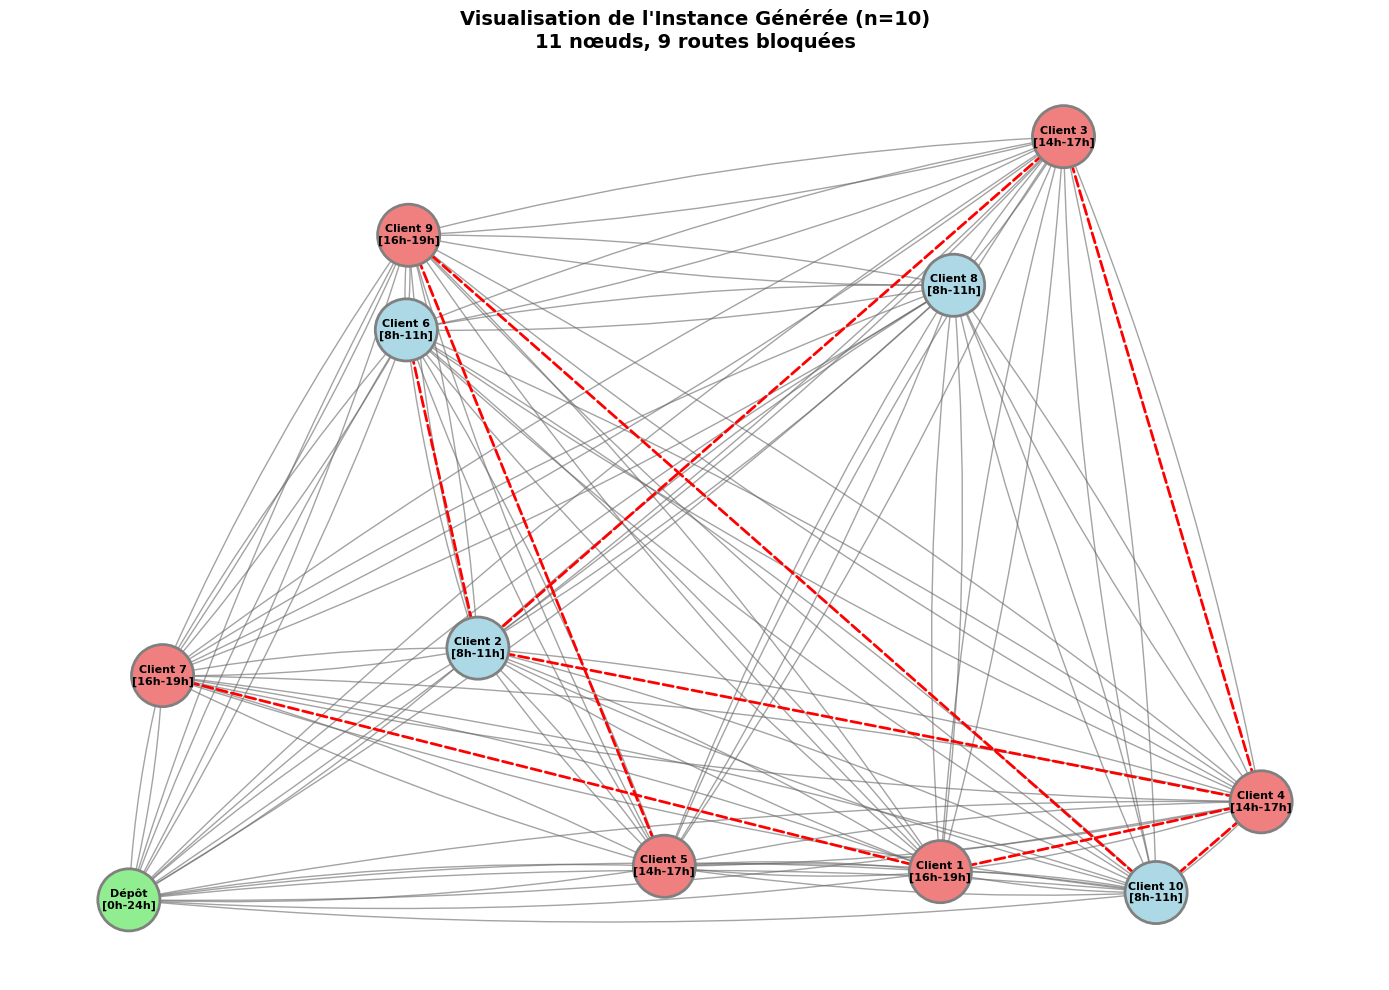


Légende :
  🟢 Dépôt (point de départ/arrivée)
  🔵 Client - fenêtre matinale
  🔴 Client - fenêtre après-midi
  ➖ Route bloquée/interdite (rouge pointillé)


In [4]:
# Visualisation graphique de l'instance générée
import networkx as nx
import matplotlib.pyplot as plt

def visualize_instance(instance: dict, title: str = "Instance Générée"):
    """Crée une visualisation graphique de l'instance."""
    G = nx.DiGraph()
    
    # Ajout des nœuds
    coords = instance['coords']
    time_windows = instance['time_windows']
    
    for node_id, (x, y) in coords.items():
        if node_id == 0:
            color = 'lightgreen'
            label = f"Dépôt\n[{time_windows[node_id][0]:.0f}h-{time_windows[node_id][1]:.0f}h]"
        else:
            # Couleur selon la fenêtre temporelle
            start = time_windows[node_id][0]
            if start < 12:
                color = 'lightblue'  # Matin
            else:
                color = 'lightcoral'  # Après-midi
            label = f"Client {node_id}\n[{time_windows[node_id][0]:.0f}h-{time_windows[node_id][1]:.0f}h]"
        
        G.add_node(node_id, pos=(x, y), label=label, color=color)
    
    # Ajout des arêtes
    normal_edges = []
    blocked_edges = []
    
    for (i, j), cost in instance['costs'].items():
        if cost == float('inf'):
            blocked_edges.append((i, j))
        else:
            normal_edges.append((i, j, cost))
    
    # Configuration de l'affichage
    plt.figure(figsize=(14, 10))
    pos = {k: v for k, v in coords.items()}
    node_colors = [G.nodes[i]['color'] for i in G.nodes()]
    
    # Dessin des nœuds
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=node_colors, 
                          edgecolors="gray", linewidths=2)
    
    # Labels des nœuds
    nx.draw_networkx_labels(G, pos, 
                           labels={i: G.nodes[i]['label'] for i in G.nodes()},
                           font_size=8, font_weight="bold")
    
    # Arêtes normales
    if normal_edges:
        nx.draw_networkx_edges(G, pos, 
                              edgelist=[(u, v) for u, v, w in normal_edges],
                              arrowstyle='->', arrowsize=15,
                              edge_color='#666666', width=1,
                              connectionstyle='arc3,rad=0.05', alpha=0.6)
    
    # Arêtes bloquées
    if blocked_edges:
        nx.draw_networkx_edges(G, pos, edgelist=blocked_edges,
                              style='dashed', edge_color='red',
                              arrowstyle='-|>', arrowsize=15, width=2)
    
    plt.title(f"{title}\n{instance['summary']['total_nodes']} nœuds, {len(blocked_edges)} routes bloquées",
             fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    
    # Légende
    print("\nLégende :")
    print("  🟢 Dépôt (point de départ/arrivée)")
    print("  🔵 Client - fenêtre matinale")
    print("  🔴 Client - fenêtre après-midi")
    print("  ➖ Route bloquée/interdite (rouge pointillé)")

visualize_instance(instance, "Visualisation de l'Instance Générée (n=10)")

### 3.4 Influence des Paramètres sur la Complexité

Pour illustrer comment les paramètres affectent la difficulté des instances, comparons plusieurs configurations :

In [5]:
# Comparaison de différentes configurations
print("=" * 70)
print("COMPARAISON DE DIFFÉRENTES CONFIGURATIONS D'INSTANCES")
print("=" * 70)

configs = [
    {"n_clients": 5, "blocked_ratio": 0.05, "time_window_type": "loose", "label": "Petite instance relaxée"},
    {"n_clients": 10, "blocked_ratio": 0.10, "time_window_type": "mixed", "label": "Instance moyenne"},
    {"n_clients": 20, "blocked_ratio": 0.15, "time_window_type": "tight", "label": "Grande instance contrainte"},
    {"n_clients": 50, "blocked_ratio": 0.20, "time_window_type": "tight", "label": "Très grande instance (test heuristiques)"},
]

results = []
for config in configs:
    gen = InstanceGenerator(
        n_clients=config["n_clients"],
        blocked_ratio=config["blocked_ratio"],
        time_window_type=config["time_window_type"],
        seed=42
    )
    inst = gen.generate()
    results.append({
        "label": config["label"],
        "n": inst["n"],
        "edges": inst["summary"]["total_edges"],
        "blocked": inst["summary"]["blocked_edges"],
        "blocked_pct": inst["summary"]["blocked_ratio"]
    })

# Affichage tableau comparatif
print(f"\n{'Configuration':<35} {'Nœuds':<8} {'Arêtes':<10} {'Bloquées':<10} {'% Bloqué':<10}")
print("-" * 75)
for r in results:
    print(f"{r['label']:<35} {r['n']+1:<8} {r['edges']:<10} {r['blocked']:<10} {r['blocked_pct']:.1f}%")

print("\n" + "=" * 70)
print("\nAnalyse :")
print("- Plus le nombre de clients augmente, plus l'espace des solutions croît factoriellement")
print("- Des fenêtres temporelles serrées ('tight') réduisent l'espace des solutions valides")
print("- Un taux élevé de routes bloquées peut rendre certaines instances infaisables")

COMPARAISON DE DIFFÉRENTES CONFIGURATIONS D'INSTANCES

Configuration                       Nœuds    Arêtes     Bloquées   % Bloqué  
---------------------------------------------------------------------------
Petite instance relaxée             6        30         1          3.3%
Instance moyenne                    11       110        9          8.2%
Grande instance contrainte          21       420        57         13.6%
Très grande instance (test heuristiques) 51       2550       490        19.2%


Analyse :
- Plus le nombre de clients augmente, plus l'espace des solutions croît factoriellement
- Des fenêtres temporelles serrées ('tight') réduisent l'espace des solutions valides
- Un taux élevé de routes bloquées peut rendre certaines instances infaisables


---

## 4. Analyse de la Complexité Théorique

L'élaboration d'algorithmes pour résoudre un problème d'optimisation combinatoire nécessite une analyse préalable de sa complexité théorique. Cette étude permet d'évaluer la difficulté intrinsèque du problème et de guider le choix des méthodes de résolution.

### 4.1 Rappels sur les Classes de Complexité

- **Classe P (Polynomiale)** : Problèmes de décision pouvant être résolus en temps polynomial par une machine déterministe.
- **Classe NP (Non-Déterministe Polynomiale)** : Problèmes de décision dont une solution proposée peut être vérifiée en un temps polynomial.
- **NP-Complet** : Problèmes les plus difficiles de la classe NP. Un problème est NP-Complet si tout problème de la classe NP peut s'y réduire en temps polynomial.
- **NP-Difficile** : Problèmes d'optimisation dont le problème de décision sous-jacent est au moins aussi difficile que les problèmes NP-Complets.

### 4.2 Complexité du Problème de Base (TSP)

Notre problème est une extension du problème du Voyageur de Commerce (TSP - Traveling Salesman Problem). 
Le problème de décision associé au TSP est : *Existe-t-il une tournée visitant chaque ville exactement une fois, retournant au point de départ, dont le coût total est inférieur ou égal à une constante $K$ ?*

**Preuve historique** : Karp (1972) a démontré que le TSP de décision est **NP-Complet**. La démonstration classique se fait par une réduction polynomiale depuis le problème du **Cycle Hamiltonien** (lui-même NP-Complet). Le TSP d'optimisation (trouver la tournée de coût minimum) est donc **NP-Difficile**.

### 4.3 Adaptation de l'Étude à notre Cas (TSPTW avec arêtes bloquées)

Notre problème spécifique (le TSPTW avec restrictions d'arêtes) ajoute deux extensions majeures au TSP classique :
1. **Les fenêtres temporelles (Time Windows)** : Chaque sommet $i$ a un intervalle de validité $[e_i, l_i]$.
2. **Les restrictions de passage** : Certaines arêtes ont un coût infini.

**Démonstration que notre problème est NP-Difficile :**

Nous pouvons démontrer que le TSPTW est NP-Difficile par **restriction**. 
Considérons une instance de notre problème TSPTW où l'on applique les paramètres suivants :
- On définit l'intervalle de temps de chaque nœud client à $[0, +\infty]$ (aucune restriction temporelle).
- On définit l'ensemble des arêtes bloquées comme un ensemble vide (toutes les routes sont possibles).
- On pose le temps de service à chaque nœud à $0$.

Dans ce cas particulier, les variables de temps $t_i$ ne contraignent plus le routage. Le problème se réduit **exactement au problème du Voyageur de Commerce (TSP)** standard.

Puisque le TSP classique est un cas particulier de notre problème (TSPTW), et que le TSP est itérativement prouvé comme étant NP-Difficile, **on en déduit que le TSPTW est au moins aussi difficile que le TSP**. Par conséquent, **notre problème cible est strictement NP-Difficile**.

**Impact des contraintes de fenêtres temporelles sur la faisabilité :**
Il est important de noter que pour le TSP standard, la recherche d'une solution réalisable est triviale si le graphe est complet. En revanche, pour le TSPTW (avec des temps restreints), Savelsbergh (1985) a démontré que **même le simple fait de trouver une solution réalisable (respectant toutes les fenêtres temporelles) est un problème NP-Complet**. 

### 4.4 Conclusion sur la Complexité et le Choix des Algorithmes

La caractérisation NP-Difficile de notre problème justifie pleinement les futures voies de résolution :
1. Les méthodes exactes (Programmation Linéaire en Nombres Entiers) seront limitées aux petites instances en raison de l'explosion combinatoire.
2. Pour les instances réelles (plus de 20-30 points), il sera mathématiquement nécessaire de faire un compromis sur l'optimalité globale et de se tourner vers des **heuristiques** ou **méta-heuristiques** (algorithmes génétiques, recherche tabou) offrant de très bonnes solutions en un temps de calcul acceptable.

## 5. Bibliographie et Références Scientifiques

### 5.1 Ouvrages Fondamentaux

1. **Garey, M. R., & Johnson, D. S. (1979).** *Computers and Intractability: A Guide to the Theory of NP-Completeness*. W. H. Freeman & Co.  
   → Référence fondamentale sur la théorie de la NP-complétude et les réductions entre problèmes.

2. **Lawler, E. L., Lenstra, J. K., Rinnooy Kan, A. H. G., & Shmoys, D. B. (1985).** *The Traveling Salesman Problem: A Guided Tour of Combinatorial Optimization*. John Wiley & Sons.  
   → Ouvrage de référence dédié spécifiquement au TSP et ses variantes.

### 5.2 Articles sur le TSP et TSPTW

3. **Karp, R. M. (1972).** Reducibility among combinatorial problems. In *Complexity of Computer Computations* (pp. 85-103). Springer.  
   → Preuve fondatrice de la NP-complétude du TSP (l'une des 21 problèmes NP-complets de Karp).

4. **Savelsbergh, M. W. P. (1985).** Local search in routing problems with time windows. *Annals of Operations Research*, 4(1), 285-305.  
   → Démonstration de la NP-complétude de la faisabilité du TSPTW et algorithmes de recherche locale.

5. **Desrochers, M., Lenstra, J. K., Savelsbergh, M. W. P., & Soumis, F. (1988).** Vehicle routing with time windows: Optimization and approximation. *Vehicle Routing: Methods and Studies*, 16(1), 65-84.  
   → Techniques de résolution pour les problèmes de tournées avec fenêtres temporelles.

### 5.3 Programmation Linéaire en Nombres Entiers (PLNE)

6. **Nemhauser, G. L., & Wolsey, L. A. (1988).** *Integer and Combinatorial Optimization*. Wiley-Interscience.  
   → Référence pour la modélisation PLNE et les méthodes de résolution (Branch & Bound, coupes).

7. **Miller, C. E., Tucker, A. W., & Zemlin, R. A. (1960).** Integer programming formulation of traveling salesman problems. *Journal of the ACM*, 7(4), 322-332.  
   → Formulation MTZ classique pour l'élimination des sous-tours dans le TSP.

### 5.4 Ressources en Ligne

8. **Applegate, D. L., Bixby, R. E., Chvátal, V., & Cook, W. J. (2006).** *The Traveling Salesman Problem: A Computational Study*. Princeton University Press.  
   → État de l'art des méthodes exactes et record de résolution (plus de 85 000 villes).

9. **TSPLIB** – Bibliothèque d'instances de référence pour le TSP : https://www.iwr.uni-heidelberg.de/groups/comopt/software/TSPLIB/  
   → Instances standards utilisées par la communauté scientifique pour comparer les algorithmes.

---

## 6. Conclusion du Livrable 1

Ce livrable a permis de :

1. ✅ **Reformuler le problème** dans un cadre formel (graphe, variables, contraintes)
2. ✅ **Démontrer la complexité** NP-Difficile du TSPTW avec restrictions d'arêtes
3. ✅ **Concevoir un générateur d'instances** paramétrable et reproductible
4. ✅ **Justifier les choix méthodologiques** pour les livrables suivants

**Perspectives pour le Livrable 2** :  
La complexité théorique analysée ci-dessus justifie l'implémentation de :
- **Méthodes exactes** (PLNE avec solveur, Branch & Bound) pour les petites instances (n ≤ 20)
- **Méta-heuristiques** (Recuit simulé, Algorithme génétique) pour les instances moyennes et grandes (n > 20)

L'étude expérimentale comparative de ces approches fera l'objet du livrable final.